# 01 - Data Ingestion Master Control

This notebook is the safe control panel for data acquisition. It plans source-specific monthly ingestion, trims each source to the requested date window, and saves visual reports under `outputs/ingestion_control` and `outputs/notebook_reports/01_data_ingestion`.

Default behavior is **dry-run only** so we do not accidentally redownload tens of GB.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('01_data_ingestion', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '01_data_ingestion')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\01_data_ingestion
Notebook log file: C:\Code\flight-disruption-prediction\logs\01_data_ingestion_20260420_175013.log


## 2. Master Controls

Set `RUN_DOWNLOADS = True` only when you intentionally want to download/rebuild raw source data.

In [2]:
from src.ingestion_control import MasterIngestionConfig, run_master_ingestion, build_monthly_plan

RUN_DOWNLOADS = False
FORCE_REBUILD = False
INGEST_START_DATE = config.get('ingestion', {}).get('master_control', {}).get('start_date', '2022-01-01')
INGEST_END_DATE = config.get('ingestion', {}).get('master_control', {}).get('end_date', '2022-06-30')
INGEST_SOURCES = config.get('ingestion', {}).get('master_control', {}).get('sources', ['opensky', 'bts', 'eurocontrol'])

control = MasterIngestionConfig(
    project_root=PROJECT_ROOT,
    start_date=pd.Timestamp(INGEST_START_DATE),
    end_date=pd.Timestamp(INGEST_END_DATE),
    sources=tuple(INGEST_SOURCES),
    max_workers=int(config.get('ingestion', {}).get('master_control', {}).get('max_workers', 8)),
    hour_start=int(config.get('ingestion', {}).get('master_control', {}).get('hour_start', 0)),
    hour_end=int(config.get('ingestion', {}).get('master_control', {}).get('hour_end', 23)),
    force=FORCE_REBUILD,
    execute_downloads=RUN_DOWNLOADS,
    raw_dir=raw_dir,
    processed_dir=processed_dir,
    outputs_dir=PROJECT_ROOT / config.get('ingestion', {}).get('master_control', {}).get('outputs_dir', 'outputs/ingestion_control'),
)

print('Date window:', control.start_date.date(), 'to', control.end_date.date())
print('Sources:', control.sources)
print('RUN_DOWNLOADS:', RUN_DOWNLOADS)

Date window: 2022-01-01 to 2022-06-30
Sources: ('opensky', 'bts', 'eurocontrol')
RUN_DOWNLOADS: False


## 3. Monthly Plan and Source-Specific Storage

In [3]:
plan = build_monthly_plan(control)
save_dataframe(plan, 'monthly_ingestion_plan_notebook', notebook_out)
save_table_image(plan, 'monthly_ingestion_plan_notebook', notebook_out, title='Monthly Ingestion Plan', max_rows=60)
display(plan)

units = plan.groupby(['source', 'storage_grain'], as_index=False)['units'].sum()
save_dataframe(units, 'planned_units_by_source', notebook_out)
display(units)

,source,month,period_start,period_end,storage_grain,units,sample_dates,monthly_output
0,opensky,2022-01,2022-01-01,2022-01-31,weekly sample dates x hourly archives,120,"2022-01-03, 2022-01-10, 2022-01-17, 2022-01-24...",C:\Code\flight-disruption-prediction\data\proc...
1,bts,2022-01,2022-01-01,2022-01-31,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...
2,eurocontrol,2022-01,2022-01-01,2022-01-31,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...
3,opensky,2022-02,2022-02-01,2022-02-28,weekly sample dates x hourly archives,96,"2022-02-07, 2022-02-14, 2022-02-21, 2022-02-28",C:\Code\flight-disruption-prediction\data\proc...
4,bts,2022-02,2022-02-01,2022-02-28,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...
5,eurocontrol,2022-02,2022-02-01,2022-02-28,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...
6,opensky,2022-03,2022-03-01,2022-03-31,weekly sample dates x hourly archives,96,"2022-03-07, 2022-03-14, 2022-03-21, 2022-03-28",C:\Code\flight-disruption-prediction\data\proc...
7,bts,2022-03,2022-03-01,2022-03-31,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...
8,eurocontrol,2022-03,2022-03-01,2022-03-31,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...
9,opensky,2022-04,2022-04-01,2022-04-30,weekly sample dates x hourly archives,96,"2022-04-04, 2022-04-11, 2022-04-18, 2022-04-25",C:\Code\flight-disruption-prediction\data\proc...


,source,storage_grain,units
0,bts,monthly zip/csv,6
1,eurocontrol,monthly parquet,6
2,opensky,weekly sample dates x hourly archives,624


## 4. Run or Dry-Run Master Ingestion

In [4]:
status_or_plan = run_master_ingestion(control)
save_dataframe(status_or_plan, 'master_ingestion_status_or_plan', notebook_out)
save_table_image(status_or_plan, 'master_ingestion_status_or_plan', notebook_out, title='Master Ingestion Status / Plan', max_rows=80)
display(status_or_plan)

,source,month,period_start,period_end,storage_grain,units,sample_dates,monthly_output,status
0,opensky,2022-01,2022-01-01,2022-01-31,weekly sample dates x hourly archives,120,"2022-01-03, 2022-01-10, 2022-01-17, 2022-01-24...",C:\Code\flight-disruption-prediction\data\proc...,PLANNED
1,bts,2022-01,2022-01-01,2022-01-31,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
2,eurocontrol,2022-01,2022-01-01,2022-01-31,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
3,opensky,2022-02,2022-02-01,2022-02-28,weekly sample dates x hourly archives,96,"2022-02-07, 2022-02-14, 2022-02-21, 2022-02-28",C:\Code\flight-disruption-prediction\data\proc...,PLANNED
4,bts,2022-02,2022-02-01,2022-02-28,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
5,eurocontrol,2022-02,2022-02-01,2022-02-28,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
6,opensky,2022-03,2022-03-01,2022-03-31,weekly sample dates x hourly archives,96,"2022-03-07, 2022-03-14, 2022-03-21, 2022-03-28",C:\Code\flight-disruption-prediction\data\proc...,PLANNED
7,bts,2022-03,2022-03-01,2022-03-31,monthly zip/csv,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
8,eurocontrol,2022-03,2022-03-01,2022-03-31,monthly parquet,1,,C:\Code\flight-disruption-prediction\data\raw\...,PLANNED
9,opensky,2022-04,2022-04-01,2022-04-30,weekly sample dates x hourly archives,96,"2022-04-04, 2022-04-11, 2022-04-18, 2022-04-25",C:\Code\flight-disruption-prediction\data\proc...,PLANNED


## 5. Dataset Inventory After Ingestion

In [5]:
inventory_paths = {
    'adsb_combined': processed_dir / 'adsb_combined.parquet',
    'bts_combined': processed_dir / 'bts_combined.parquet',
    'eurocontrol_combined': processed_dir / 'eurocontrol_combined.parquet',
    'metar': PROJECT_ROOT / paths.get('metar_data_file', 'data/raw/metar.parquet'),
}
inventory = save_dataset_inventory(inventory_paths, notebook_out)
display(inventory)

,dataset,path,exists,size_mb,rows,columns,min_time,max_time
0,adsb_combined,C:\Code\flight-disruption-prediction\data\proc...,True,45029.80,1296709098,20,1641168000,1656374390
1,bts_combined,C:\Code\flight-disruption-prediction\data\proc...,True,13.24,471539,26,2022-05-01 04:59:00+00:00,2022-06-01 09:15:00+00:00
2,eurocontrol_combined,C:\Code\flight-disruption-prediction\data\proc...,True,131.20,4339106,12,2022-01-01 00:00:00+00:00,2022-06-30 23:58:15+00:00
3,metar,C:\Code\flight-disruption-prediction\data\raw\...,True,0.09,14383,6,2022-05-01 00:00:00+00:00,2022-05-30 23:56:00+00:00


## 6. Visual Outputs

monthly_ingestion_plan_notebook.png


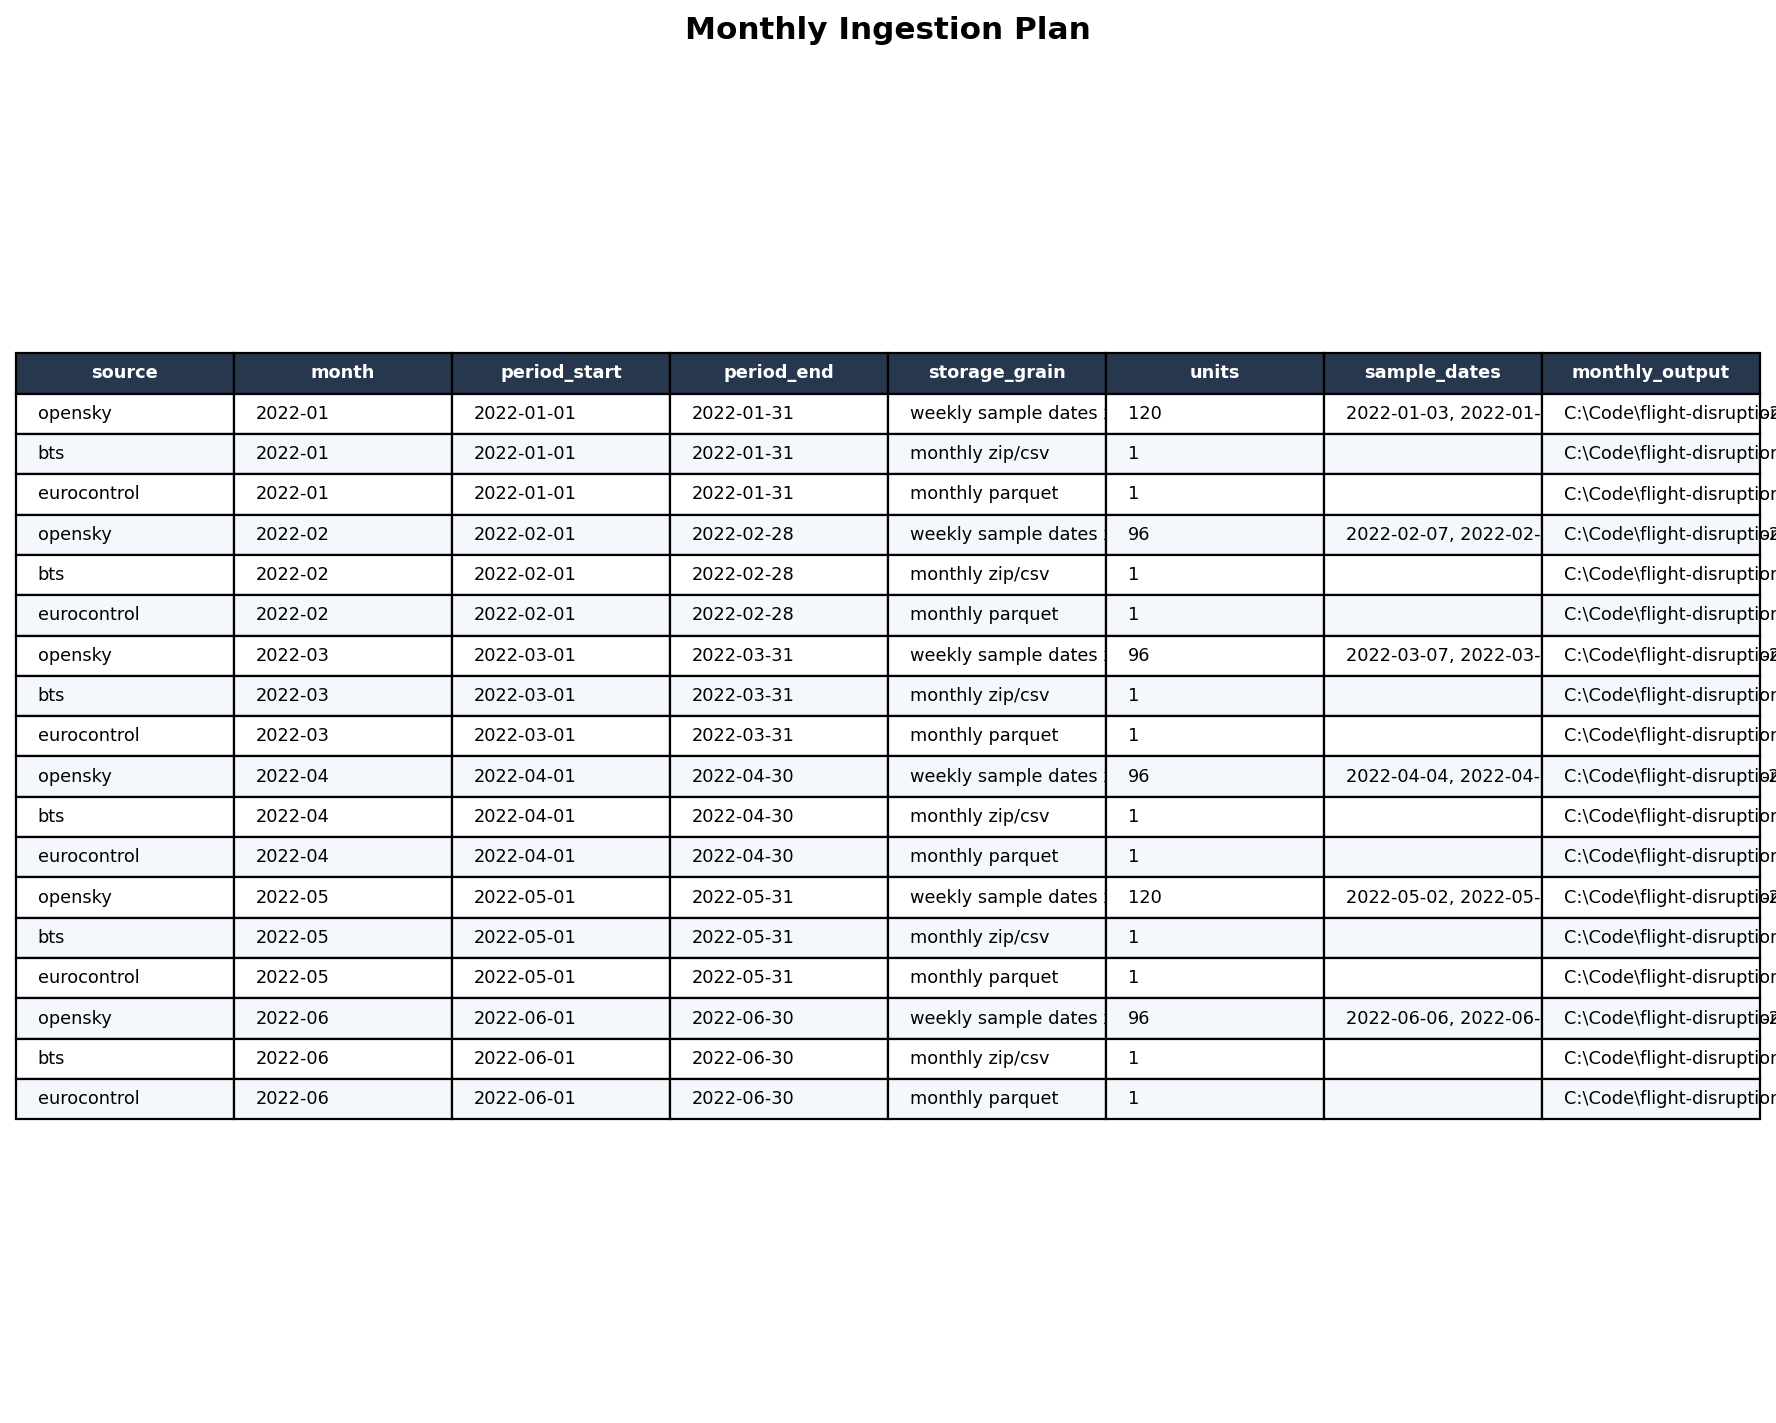

dataset_inventory.png


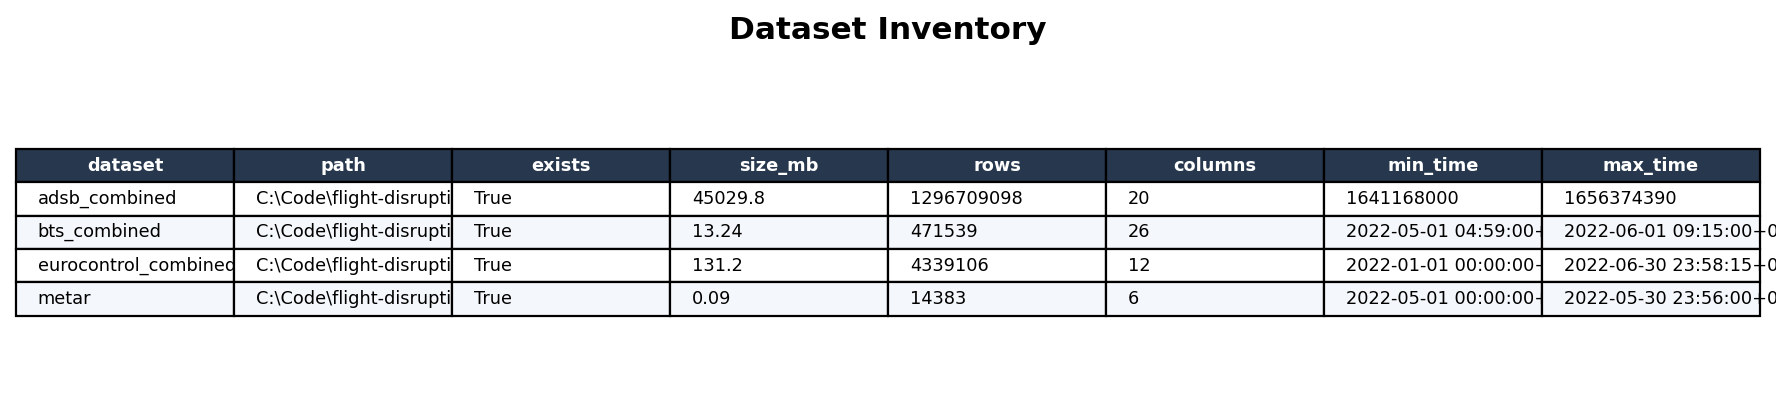

dataset_sizes.png


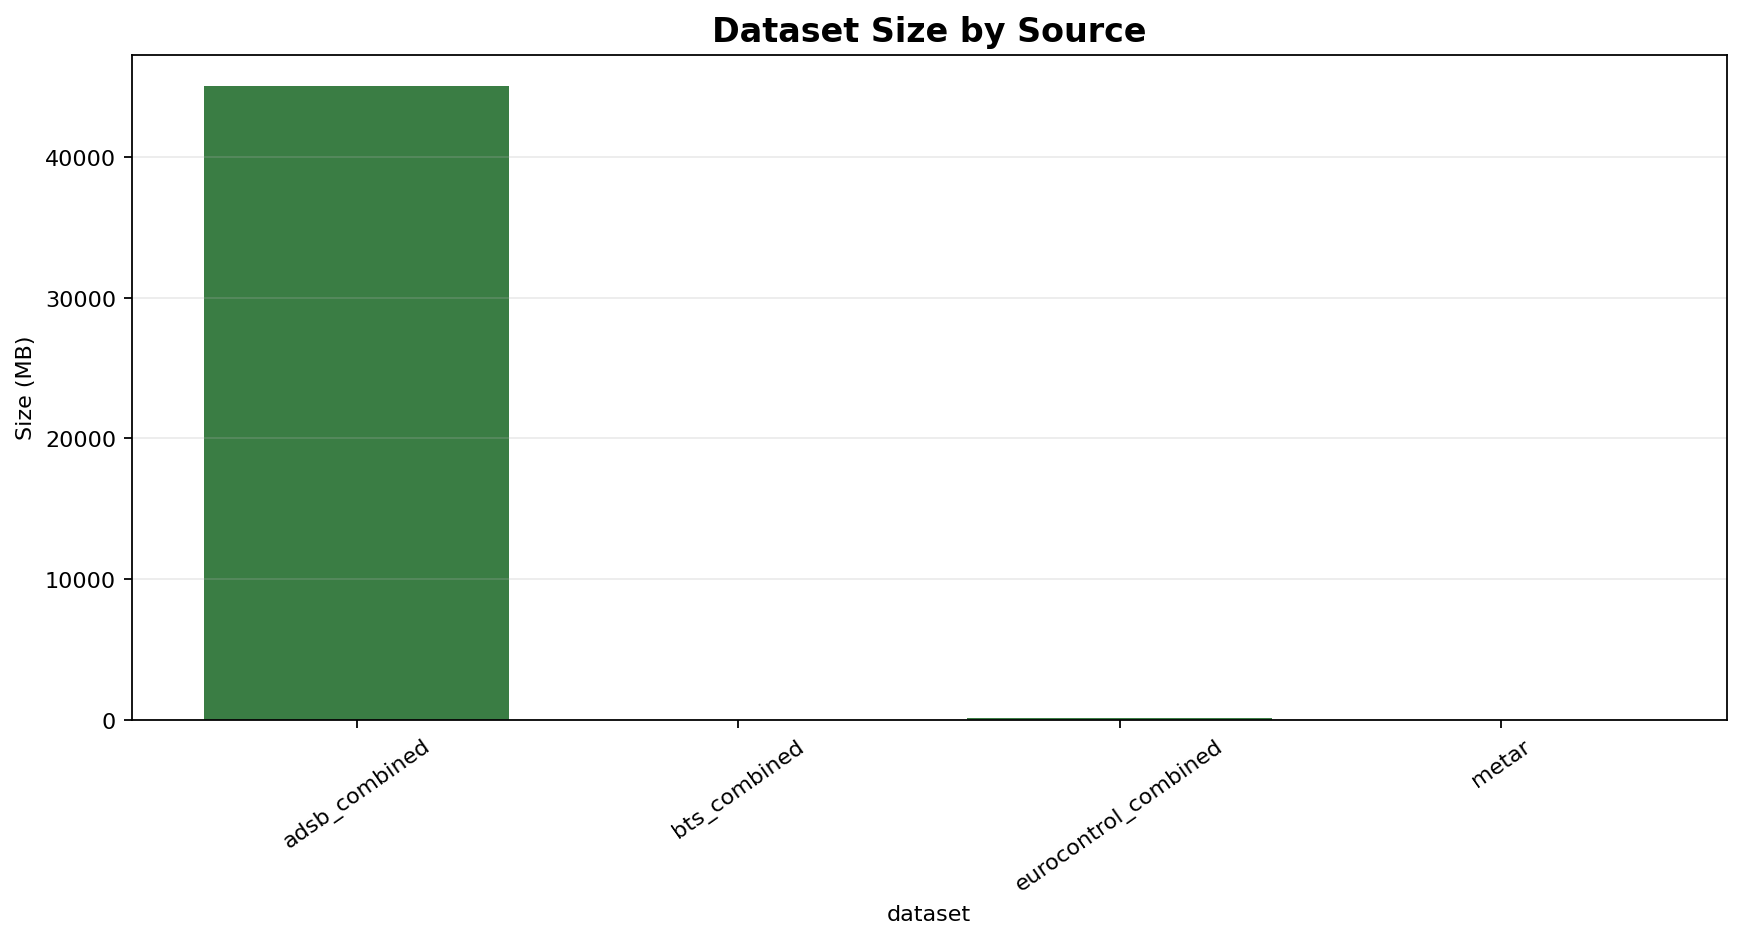

ingestion_data_flow.png


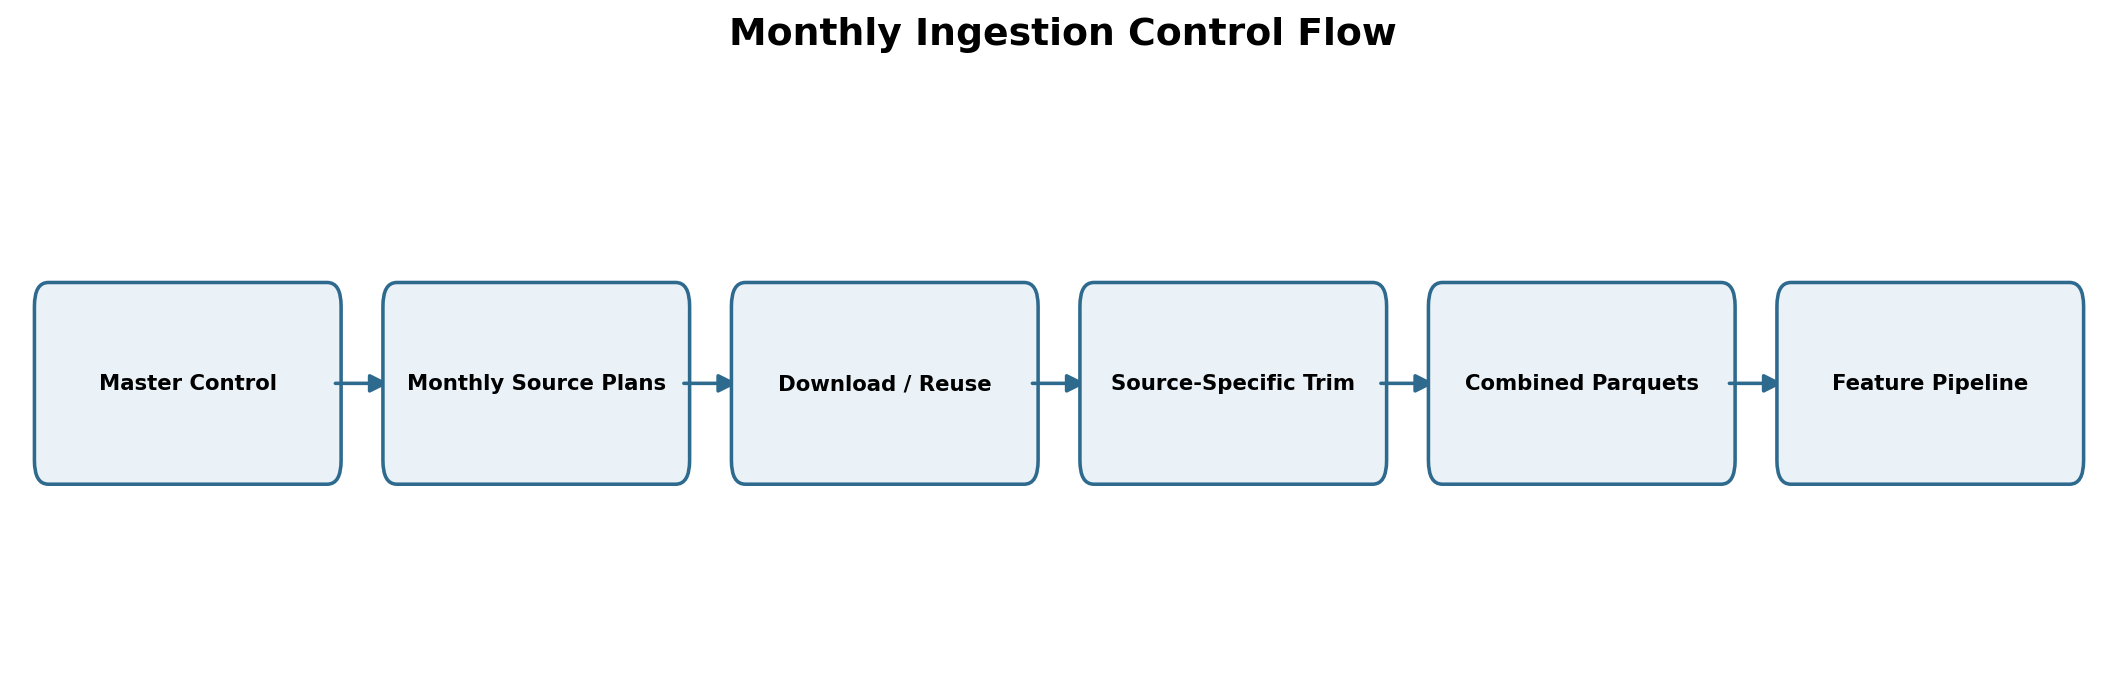

monthly_units_by_source.png


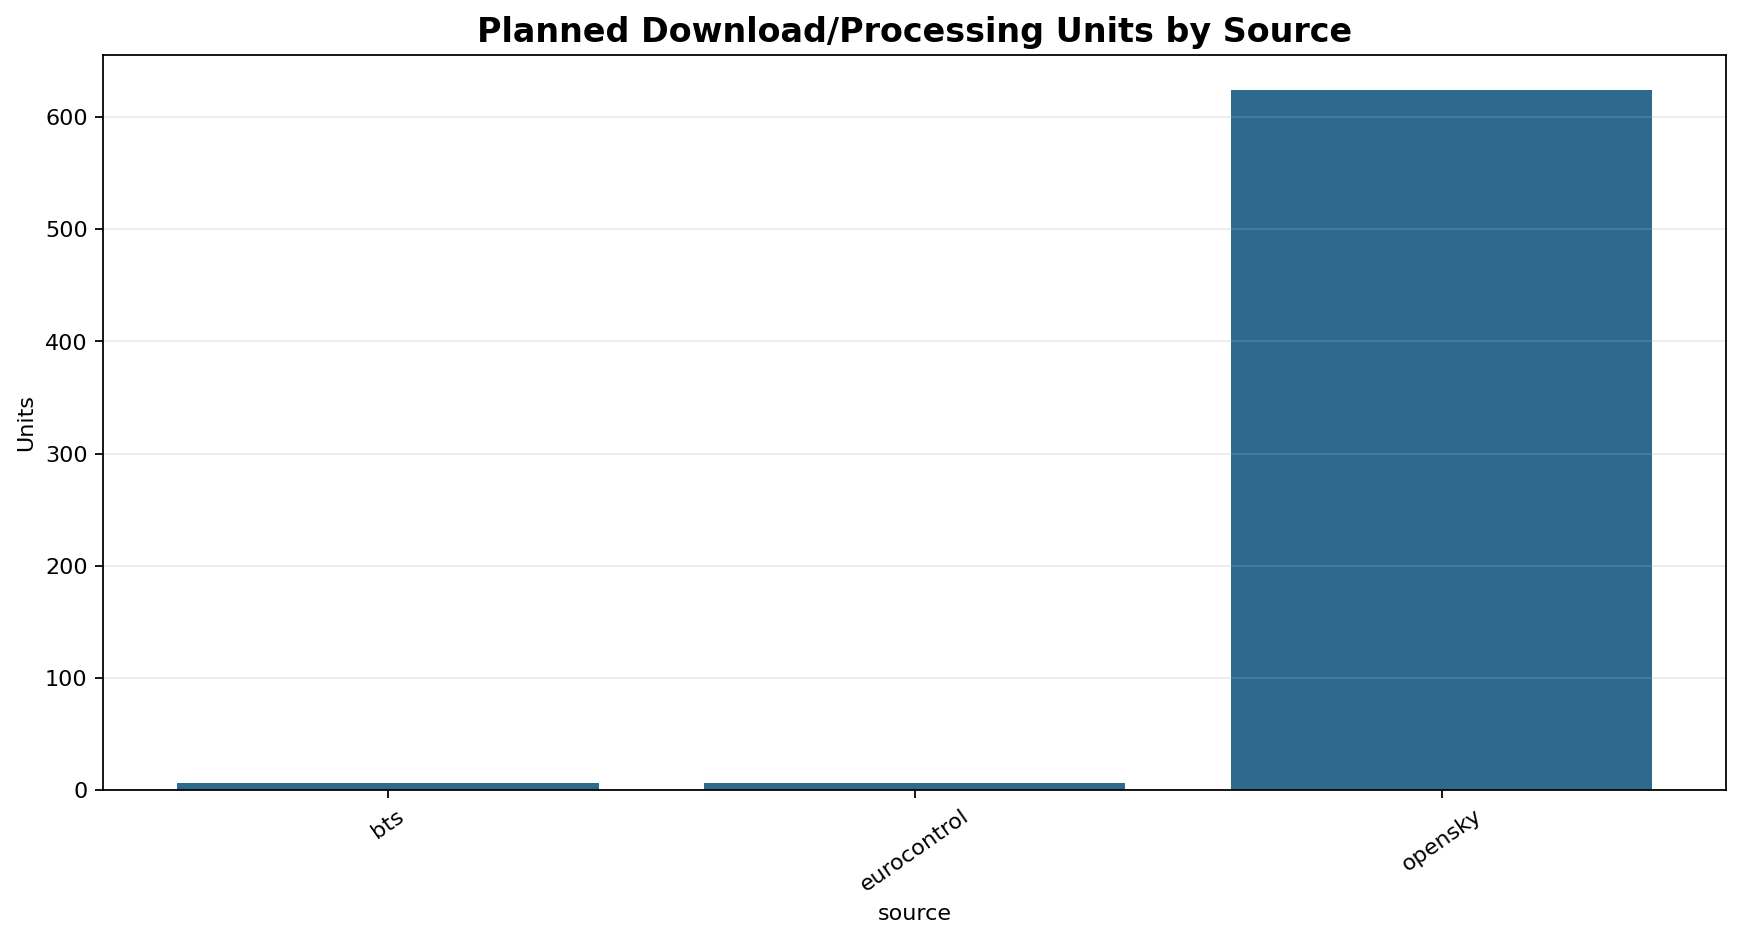

In [6]:
for image_name in [
    'monthly_ingestion_plan_notebook.png',
    'dataset_inventory.png',
    'dataset_sizes.png',
]:
    image_path = notebook_out / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))

for image_name in ['ingestion_data_flow.png', 'monthly_units_by_source.png']:
    image_path = PROJECT_ROOT / 'outputs' / 'ingestion_control' / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))

## 7. Next Step

After ingestion is complete, run notebook `03_feature_extraction.ipynb` or CLI:

```powershell
python main.py --stage features --force
```